NameError: name 'np' is not defined

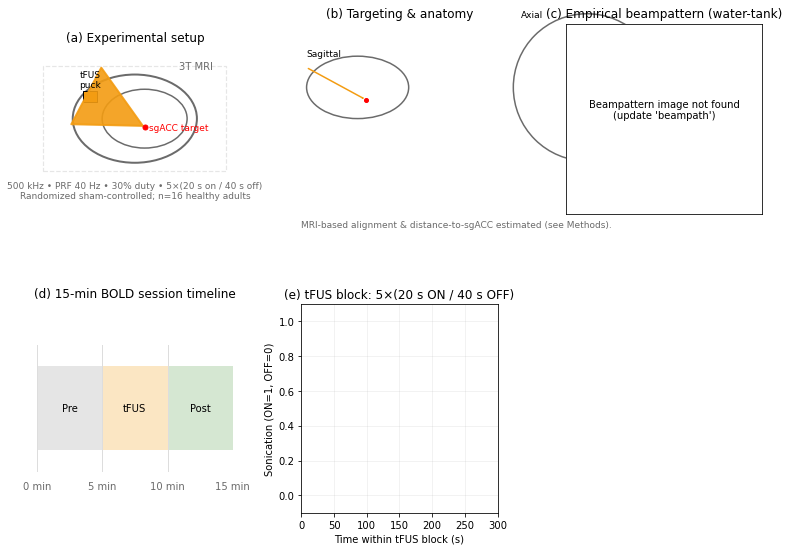

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, ArrowStyle
from PIL import Image
import os
from pathlib import Path
import numpy as np

# === Colors ===
orange = "#f39c12"
green  = "#59a14f"
gray   = "#6b6b6b"
light_gray = "#e6e6e6"

# === Canvas ===
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1,1.1], hspace=0.45, wspace=0.35)

# (a) Experimental setup
ax_a = fig.add_subplot(gs[0,0])
ax_a.set_title("(a) Experimental setup")
ax_a.set_aspect('equal'); ax_a.axis('off')
ax_a.add_patch(patches.Ellipse((0.0, 0.0), 3.8, 2.7, fill=False, lw=2, ec=gray))            # head
ax_a.add_patch(patches.Ellipse((0.3, 0.0), 2.6, 1.8, fill=False, lw=1.5, ec=gray))          # brain
ax_a.add_patch(patches.Rectangle((-1.6, 0.5), 0.45, 0.35, facecolor=orange, edgecolor='k')) # puck
ax_a.text(-1.38, 0.9, "tFUS\npuck", ha="center", va="bottom", fontsize=9)
sgacc = (0.3, -0.25)
ax_a.plot(*sgacc, 'o', color='red', ms=5)
ax_a.text(0.42, -0.28, "sgACC target", color='red', fontsize=9, va='center')
ax_a.add_patch(FancyArrowPatch(posA=(-1.4, 0.65), posB=sgacc,
                               arrowstyle=ArrowStyle("Simple", head_width=8, head_length=8),
                               mutation_scale=8, color=orange, lw=2, alpha=0.9))
ax_a.add_patch(patches.Rectangle((-2.8, -1.6), 5.6, 3.2, fill=False, ls='--', ec=light_gray, lw=1.2)) # MRI bore
ax_a.text(2.4, 1.5, "3T MRI", color=gray, ha="right")
ax_a.text(0, -1.9, "500 kHz • PRF 40 Hz • 30% duty • 5×(20 s on / 40 s off)\n"
                   "Randomized sham-controlled; n=16 healthy adults",
          ha="center", va="top", fontsize=9, color=gray)
ax_a.set_xlim(-3.0, 3.0); ax_a.set_ylim(-2.2, 2.2)

# (b) Targeting & anatomy
ax_b = fig.add_subplot(gs[0,1])
ax_b.set_title("(b) Targeting & anatomy"); ax_b.axis('off')

left = fig.add_axes([ax_b.get_position().x0, ax_b.get_position().y0+0.07, 0.12, 0.25])
left.set_aspect('equal'); left.axis('off')
left.add_patch(patches.Ellipse((0,0), 1.8, 1.1, fill=False, ec=gray, lw=1.5))
left.plot(0.15, -0.22, 'o', color='red', ms=4)
left.text(-0.9, 0.55, "Sagittal", fontsize=9)
left.add_patch(FancyArrowPatch(posA=(-0.9, 0.35), posB=(0.15, -0.22), color=orange, arrowstyle='->', lw=1.5))

right = fig.add_axes([ax_b.get_position().x0+0.18, ax_b.get_position().y0+0.07, 0.25, 0.25])
right.set_aspect('equal'); right.axis('off')
right.add_patch(patches.Circle((0,0), radius=1.0, fill=False, ec=gray, lw=1.5))
right.plot(0.02, -0.25, 'o', color='red', ms=4)
right.text(-0.9, 0.95, "Axial", fontsize=9)

ax_b.text(ax_b.get_position().x0, ax_b.get_position().y0-0.02,
          "MRI-based alignment & distance-to-sgACC estimated (see Methods).",
          transform=fig.transFigure, fontsize=9, color=gray)

# (c) Empirical beampattern
ax_c = fig.add_subplot(gs[0,2])
ax_c.set_title("(c) Empirical beampattern (water-tank)")
beampath = "/mnt/data/beampattern_60mm_corrected.png"  # <-- change if needed
if os.path.exists(beampath):
    img = Image.open(beampath)
    ax_c.imshow(img, extent=[-3,3,9,0])  # extent ≈ lateral offset (cm) vs depth (cm)
    ax_c.set_xlabel("Lateral offset (cm)"); ax_c.set_ylabel("Depth (cm)")
    ax_c.axhline(6.0, ls='--', color='w', lw=1.5, alpha=0.9)
    ax_c.text(2.85, 6.2, "sgACC depth (~6 cm)", color='w', ha='right', va='bottom', fontsize=9)
else:
    ax_c.text(0.5, 0.5, "Beampattern image not found\n(update 'beampath')", ha='center')
    ax_c.set_xticks([]); ax_c.set_yticks([])

# (d) Session timeline
ax_d = fig.add_subplot(gs[1,0])
ax_d.set_title("(d) 15-min BOLD session timeline")
ax_d.set_xlim(0, 15); ax_d.set_ylim(0, 1); ax_d.axis('off')

def bar(ax, x0, x1, color, label):
    ax.add_patch(patches.Rectangle((x0, 0.3), x1-x0, 0.4, facecolor=color, edgecolor='none', alpha=0.25))
    ax.text((x0+x1)/2, 0.5, label, ha='center', va='center')

bar(ax_d, 0, 5, "#999999", "Pre")
bar(ax_d, 5, 10, orange, "tFUS")
bar(ax_d, 10, 15, green, "Post")
for t in range(0, 16, 5):
    ax_d.plot([t, t], [0.2, 0.8], color="#dddddd", lw=1)
    ax_d.text(t, 0.15, f"{t} min", ha='center', va='top', color=gray)

# (e) Sonication train zoom
ax_e = fig.add_subplot(gs[1,1])
ax_e.set_title("(e) tFUS block: 5×(20 s ON / 40 s OFF)")
ax_e.set_xlim(0, 300); ax_e.set_ylim(-0.1, 1.1)
ax_e.set_xlabel("Time within tFUS block (s)")
ax_e.set_ylabel("Sonication (ON=1, OFF=0)")
ax_e.grid(True, alpha=0.2)

t = np.arange(0, 300, 0.1)
signal = np.zeros_like(t)
for k in range(5):
    on_start = k*60
    on_end = on_start + 20
    signal[(t>=on_start) & (t<on_end)] = 1.0
ax_e.plot(t, signal, color=orange, lw=2)

# PRF inset
inset = fig.add_axes([ax_e.get_position().x1-0.18, ax_e.get_position().y1-0.12, 0.16, 0.10])
inset.set_title("PRF 40 Hz, 30% duty", fontsize=8)
inset.set_xlim(0, 1.0); inset.set_ylim(-0.05, 1.05); inset.axis('off')
tt = np.linspace(0, 1.0, 6000)
prf = np.zeros_like(tt)
period = 1/40.0; duty = 0.30
for n in range(int(1.0/period)+1):
    start = n*period; end = min(start + duty*period, 1.0)
    prf[(tt>=start) & (tt<end)] = 1.0
inset.plot(tt, prf, color=orange, lw=1.5)

# (f) Analysis workflow
ax_f = fig.add_subplot(gs[1,2])
ax_f.set_title("(f) Analysis workflow (overview)")
ax_f.axis('off')

def add_box(ax, xy, text, fc="#ffffff"):
    x, y = xy; w, h = 1.8, 0.55
    box = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.03",
                                 ec=gray, fc=fc, lw=1.2)
    ax.add_patch(box)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=10)
    return (x, y, w, h)

def add_arrow(ax, start, end):
    sx, sy, sw, sh = start; ex, ey, ew, eh = end
    ax.add_patch(FancyArrowPatch((sx+sw, sy+sh/2), (ex, ey+eh/2), arrowstyle='->',
                                 mutation_scale=12, lw=1.5, color=gray))

ax_f.set_xlim(0, 8); ax_f.set_ylim(0, 3)
b1 = add_box(ax_f, (0.3, 1.9), "fMRIPrep\n(preprocessing)")
b2 = add_box(ax_f, (2.7, 1.9), "sgACC seed FC\n(Pre / tFUS / Post)")
b3 = add_box(ax_f, (5.1, 1.9), "Mixed-effects model\nTime × Condition\n(primary: Pre→Post)")
add_arrow(ax_f, b1, b2); add_arrow(ax_f, b2, b3)

ax_f.text(0.3, 1.2, "Outputs:\n• FC matrices\n• Subject means\n• QC metrics", fontsize=9, ha='left', va='top', color=gray)
ax_f.text(2.7, 1.2, "Compute whole-brain FC per window\nActive vs Sham", fontsize=9, ha='left', va='top', color=gray)
ax_f.text(5.1, 1.2, "Estimate interaction\n(effect beyond sham)", fontsize=9, ha='left', va='top', color=gray)

# Save
outdir = Path("/mnt/data"); outdir.mkdir(parents=True, exist_ok=True)
out_png = outdir / "process_figure.png"
out_pdf = outdir / "process_figure.pdf"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print("Saved:", out_png, out_pdf)

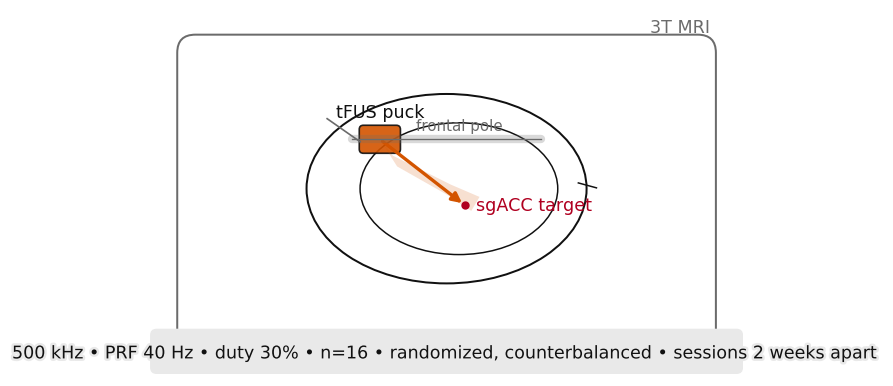

In [3]:
# ==== MRI + tFUS schematic (Nature-style) ====================================
# Produces PNG, SVG, and PDF vector outputs.

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Ellipse, Polygon, FancyArrowPatch
from matplotlib import patheffects as pe
from pathlib import Path

# Style
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10.5,
    "axes.linewidth": 0.8,
})

black = "#111111"
gray = "#6b6b6b"
lightgray = "#e9e9e9"
accent = "#d35400"   # ultrasound elements
target = "#b00020"   # sgACC focus

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-3.6, 3.6)
ax.set_ylim(-2.2, 2.2)

# MRI bore
ax.add_patch(FancyBboxPatch(
    (-3.25, -1.9), 6.5, 3.8,
    boxstyle="round,pad=0.02,rounding_size=0.22",
    linewidth=1.2, edgecolor=gray, facecolor="none"
))
ax.text(3.2, 1.9, "3T MRI", ha="right", va="bottom", color=gray)

# Head silhouette (clean cartoon: outer skull + inner brain contour)
ax.add_patch(Ellipse((0.0, 0.05), 3.4, 2.3, facecolor="none", edgecolor=black, linewidth=1.2))
ax.add_patch(Ellipse((0.15, 0.05), 2.4, 1.6, facecolor="none", edgecolor=black, linewidth=0.9))
ax.plot([1.6, 1.82], [0.12, 0.06], color=black, lw=0.9)  # tiny profile hint

# Headband + tFUS puck
ax.plot([-1.15, 1.15], [0.65, 0.65], color=gray, lw=5, alpha=0.25, solid_capstyle="round")
ax.plot([-1.15, 1.15], [0.65, 0.65], color=gray, lw=0.8)  # subtle outline
ax.add_patch(FancyBboxPatch(
    (-1.05, 0.49), 0.48, 0.32,
    boxstyle="round,pad=0.01,rounding_size=0.05",
    linewidth=1.0, edgecolor=black, facecolor=accent, alpha=0.9
))
ax.plot([-1.05, -1.45], [0.62, 0.9], color=gray, lw=1.0)  # cable hint
ax.text(-0.81, 0.87, "tFUS puck", ha="center", va="bottom", color=black)

# sgACC target + beam
focus_xy = (0.22, -0.15)  # approximate sgACC locus
ax.scatter(*focus_xy, s=16, c=target, zorder=5)
ax.text(0.36, -0.15, "sgACC target", color=target, va="center", ha="left")

beam_poly = [[-0.81, 0.65], [-0.65, 0.45], [0.05, 0.10], [0.40, -0.05],
             [0.30, -0.22], [0.00, -0.02], [-0.60, 0.32]]
ax.add_patch(Polygon(beam_poly, closed=True, facecolor=accent, edgecolor="none", alpha=0.18))
ax.add_patch(FancyArrowPatch(posA=(-0.81, 0.65), posB=focus_xy,
                             arrowstyle="-|>", mutation_scale=12,
                             color=accent, lw=2.0))

# Minimal label
ax.text(0.15, 0.75, "frontal pole", color=gray, fontsize=9, ha="center")

# Info strip (echoing EMBS parameters)
strip = FancyBboxPatch((-3.6, -2.2), 7.2, 0.55,
                       boxstyle="round,pad=0.0,rounding_size=0.08",
                       linewidth=0, facecolor=lightgray)
ax.add_patch(strip)
info = "500 kHz • PRF 40 Hz • duty 30% • n=16 • randomized, counterbalanced • sessions 2 weeks apart"
ax.text(0, -1.95, info, ha="center", va="center", color=black,
        path_effects=[pe.withStroke(linewidth=3, foreground=lightgray)])

# Export
out = Path("fig_component_mri_tfus_setup")
for ext in (".png", ".svg", ".pdf"):
    plt.savefig(out.with_suffix(ext), bbox_inches="tight")
plt.show()

Saved: tfus_cadence_and_envelope.png tfus_cadence_and_envelope.svg tfus_cadence_and_envelope.pdf


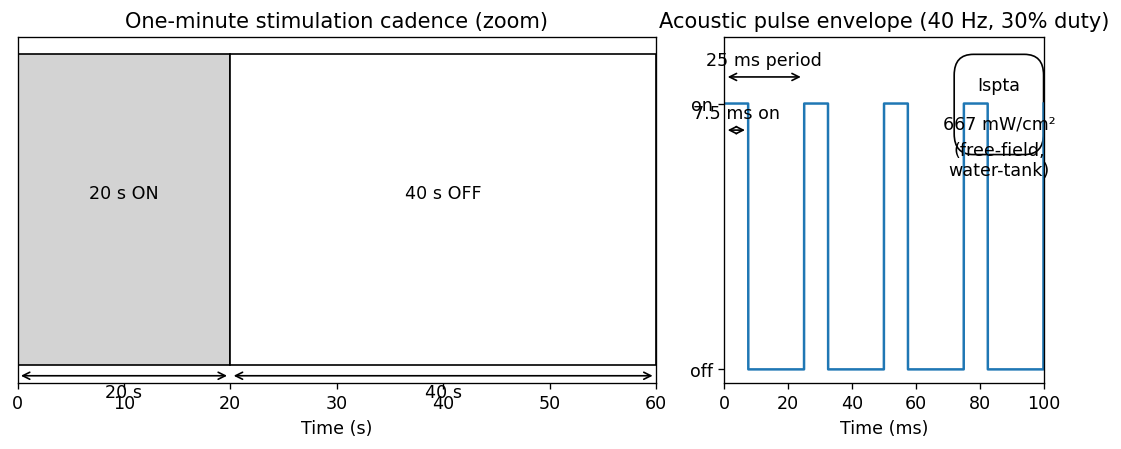

In [4]:
# ------------------------------------------------------------
# Figure: 1-minute cadence + acoustic envelope schematic
# - Left: 60 s zoom with 20 s ON / 40 s OFF
# - Right: envelope of 40 Hz PRF, 30% duty (25 ms period, 7.5 ms on)
# - Callout: Ispta = 667 mW/cm² (free-field, water-tank)
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from pathlib import Path

def envelope_square(t, prf_hz=40.0, duty=0.30, amp=1.0):
    """Square-envelope (no carrier): period=1/PRF, 'duty' fraction ON."""
    period = 1.0 / prf_hz
    on_time = duty * period
    mod = np.mod(t, period)
    return np.where(mod < on_time, amp, 0.0)

# Figure canvas (two panels laid out cleanly)
fig = plt.figure(figsize=(9.5, 4.0))
ax_left  = fig.add_axes([0.07, 0.18, 0.56, 0.72])  # left panel
ax_right = fig.add_axes([0.69, 0.18, 0.28, 0.72])  # right panel

# ---------------------------
# Left panel: 60 s cadence
# ---------------------------
T_total = 60.0
on_dur  = 20.0
off_dur = 40.0

ax_left.set_xlim(0, T_total)
ax_left.set_ylim(0, 1)
ax_left.set_yticks([])
ax_left.set_xlabel("Time (s)")
ax_left.set_title("One-minute stimulation cadence (zoom)")

# 20 s ON block (gray) then 40 s OFF (white)
ax_left.add_patch(Rectangle((0,       0.05), on_dur,    0.90, linewidth=1.0, edgecolor="black", facecolor="lightgray"))
ax_left.add_patch(Rectangle((on_dur,  0.05), off_dur,   0.90, linewidth=1.0, edgecolor="black", facecolor="white"))
ax_left.text(on_dur/2,            0.55, "20 s ON",  ha="center", va="center")
ax_left.text(on_dur+off_dur/2.0,  0.55, "40 s OFF", ha="center", va="center")

# Brackets showing durations
ax_left.annotate("", xy=(0, 0.02), xytext=(on_dur,           0.02), arrowprops=dict(arrowstyle="<->", lw=1.0))
ax_left.annotate("", xy=(on_dur,0.02), xytext=(on_dur+off_dur,0.02), arrowprops=dict(arrowstyle="<->", lw=1.0))
ax_left.text(on_dur/2,             0.0, "20 s", ha="center", va="top")
ax_left.text(on_dur+off_dur/2.0,   0.0, "40 s", ha="center", va="top")

# ---------------------------
# Right panel: pulse envelope
# ---------------------------
# Show ~4 periods so the cadence is obvious (100 ms total)
t_end = 0.100  # 100 ms
t = np.linspace(0, t_end, 2000)
env = envelope_square(t, prf_hz=40.0, duty=0.30, amp=1.0)

ax_right.plot(t*1000.0, env, lw=1.5)
ax_right.set_xlim(0, t_end*1000.0)
ax_right.set_ylim(-0.05, 1.25)
ax_right.set_xlabel("Time (ms)")
ax_right.set_yticks([0, 1])
ax_right.set_yticklabels(["off", "on"])
ax_right.set_title("Acoustic pulse envelope (40 Hz, 30% duty)")

# Period and "on" annotations for the first cycle
period_ms = 1000.0/40.0  # 25 ms
on_ms = 0.30 * period_ms # 7.5 ms

ax_right.annotate("", xy=(0, 1.10), xytext=(period_ms, 1.10),
                  arrowprops=dict(arrowstyle="<->", lw=1.0))
ax_right.text(period_ms/2, 1.13, f"{period_ms:.0f} ms period", ha="center", va="bottom")

ax_right.annotate("", xy=(0, 0.90), xytext=(on_ms, 0.90),
                  arrowprops=dict(arrowstyle="<->", lw=1.0))
ax_right.text(on_ms/2, 0.93, f"{on_ms:.1f} ms on", ha="center", va="bottom")

# Small callout box with Ispta
box = FancyBboxPatch((0.74, 0.68), 0.24, 0.25, transform=ax_right.transAxes,
                     boxstyle="round,pad=0.02,rounding_size=0.06",
                     facecolor="white", edgecolor="black", linewidth=1.0)
ax_right.add_artist(box)
ax_right.text(0.86, 0.835, "Ispta",            ha="center", va="bottom", transform=ax_right.transAxes)
ax_right.text(0.86, 0.75,  "667 mW/cm²",       ha="center", va="center", transform=ax_right.transAxes)
ax_right.text(0.86, 0.70,  "(free-field,\nwater-tank)", ha="center", va="top", transform=ax_right.transAxes)

# Export
base = Path("tfus_cadence_and_envelope")
for ext in (".png", ".svg", ".pdf"):
    fig.savefig(base.with_suffix(ext), bbox_inches="tight")

print("Saved:", base.with_suffix(".png"), base.with_suffix(".svg"), base.with_suffix(".pdf"))
plt.show()